# 05. 전이학습 — ResNet18

**이 노트북의 목적**

`04`는 15,484장만으로 밑바닥부터 배웠다. 여기서는 ImageNet 128만 장으로 미리 학습된 특징을
가져와 마지막 층만 우리 문제에 맞게 바꾼다.

`pro1`(헬멧)에서 `efficientnet_v2_s`로 한 것과 같은 구조다. 거기서는 `backbone.features`만
떼어내고 `nn.Linear(1280, 1)`을 붙였는데, 여기서는 ResNet18의 `fc`를 `nn.Identity()`로 바꾸고
12클래스 head를 붙인다.

**두 가지를 비교한다**

| 실험 | 방식 | 학습되는 것 |
|---|---|---|
| `frozen` | backbone 동결 | head만 (약 6천 개) |
| `finetune` | backbone 해제 | 전체 (약 1,120만 개) |

`pro1`은 `freeze=True`만 써봤다. 동결을 풀면 어떻게 되는지가 이 노트북의 추가 질문이다.

**왜 ResNet18인가**: `pro1`의 EfficientNetV2-S(2,100만 파라미터)나 `pro2`의 ResNetV2-50(2,376만)보다
가볍다(1,120만). 12클래스에 15,484장이면 큰 모델은 과적합하기 쉽고, 에폭당 시간도 짧아
실험을 여러 번 돌릴 수 있다.

**출력물**: `models/transfer_{tag}_{exp}.pt`, `metrics/experiments.csv` 갱신

## 0. 설정

`04`와 달라지는 것이 두 가지다.

**입력 크기 224.** ImageNet 사전학습 모델은 224x224로 학습됐다. 128을 넣으면 마지막 특징맵이
너무 작아져 사전학습의 이점을 잃는다.

**정규화는 ImageNet 통계.** 우리 데이터셋 통계가 아니다. 사전학습 가중치가 ImageNet 분포를
전제로 만들어졌기 때문에, 정규화를 바꾸면 그 전제가 깨진다. `pro1`이 `normalize="simple"`과
`"imagenet"`을 분기해서 전이학습에만 후자를 쓴 것과 같은 이유다.

In [1]:
import os, json, time, copy, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, confusion_matrix,
                             classification_report, roc_auc_score)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "CUDA 미탐지 - 커널/드라이버를 확인하세요"
device = torch.device("cuda")

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print(torch.__version__)
print(torch.cuda.get_device_name(0))

2.11.0+cu128
NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
SPLIT_TAG = "v2"        # "v2" (그룹 인지) 또는 "v1" (단순 계층) - 04와 같은 값으로

IMAGE_SIZE      = 224   # ImageNet 사전학습 규격
BATCH_SIZE      = 64
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 15
LR_FROZEN       = 5e-4  # pro1과 동일
LR_FINETUNE     = 1e-4  # 전체를 풀 때는 낮춰야 사전학습 특징이 망가지지 않는다
PATIENCE        = 4
NUM_WORKERS     = 0

OUT = Path("outputs/garbage")
split     = pd.read_csv(OUT / "metrics" / f"split_{SPLIT_TAG}.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
nstats    = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))
cw        = pd.read_csv(OUT / "metrics" / f"class_weights_{SPLIT_TAG}.csv")

classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

train_df = split[split.split == "train"].reset_index(drop=True)
val_df   = split[split.split == "val"].reset_index(drop=True)
test_df  = split[split.split == "test"].reset_index(drop=True)

IMAGENET_MEAN = nstats["imagenet_mean"]
IMAGENET_STD  = nstats["imagenet_std"]

print(f"분할 {SPLIT_TAG} | train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
print(f"입력 {IMAGE_SIZE}px | 정규화 ImageNet {IMAGENET_MEAN} {IMAGENET_STD}")

분할 v2 | train 10,838 | val 2,323 | test 2,323
입력 224px | 정규화 ImageNet [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]


## 1. 데이터셋

증강 정책은 `04`와 같다. 유리 3종의 Hue가 정답 신호라는 `01`의 분석 결과 때문에
`hue=0.0`을 유지한다. 입력 크기와 정규화만 바뀐다.

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.05, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class GarbageDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths  = frame["path"].tolist()
        self.labels = frame["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]


def make_loaders():
    tr = DataLoader(GarbageDataset(train_df, train_tf),
                    batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    va = DataLoader(GarbageDataset(val_df, eval_tf),
                    batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    te = DataLoader(GarbageDataset(test_df, eval_tf),
                    batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    return tr, va, te


train_loader, val_loader, test_loader = make_loaders()
xb, yb = next(iter(train_loader))
print(f"입력 배치 {tuple(xb.shape)}")
print(f"정규화 범위 {xb.min():.3f} ~ {xb.max():.3f}")   # ImageNet 정규화라 음수가 나온다

입력 배치 (64, 3, 224, 224)
정규화 범위 -2.118 ~ 2.640


## 2. 모델

`pro1`의 `TransferModel`과 같은 구조에 한 가지를 더했다.

**BatchNorm 처리.** `pro1`은 `requires_grad = False`로 backbone을 동결했는데, 이것만으로는
BatchNorm의 이동평균(running mean/var)이 계속 갱신된다. `requires_grad`는 **역전파로 학습되는
파라미터**를 막을 뿐이고, BN 통계는 순전파에서 갱신되는 버퍼라 별개다. 그래서 "동결했다"고
했지만 실제로는 backbone이 조금씩 변한다.

진짜로 고정하려면 backbone을 `eval()` 모드로 둬야 한다. 아래 `train()` 오버라이드가 그 역할이다.
`frozen` 실험이 정말 "특징 추출기로만 쓰는" 조건이 되도록 하기 위한 처리다.

In [5]:
class TransferModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES, freeze=True, p_drop=0.3):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        backbone = models.resnet18(weights=weights)

        n_feat = backbone.fc.in_features      # 512
        backbone.fc = nn.Identity()           # 분류기를 떼어내고 특징만 반환
        self.backbone = backbone
        self.frozen = freeze

        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(n_feat, n_classes),
        )

    def train(self, mode=True):
        # 동결 실험에서는 backbone의 BatchNorm 통계까지 고정한다
        super().train(mode)
        if self.frozen and mode:
            self.backbone.eval()
        return self

    def forward(self, x):
        return self.head(self.backbone(x))


for fz in [True, False]:
    m = TransferModel(freeze=fz)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"freeze={str(fz):5s} 전체 {total:,} | 학습 대상 {trainable:,} "
          f"({100 * trainable / total:.2f}%)")
    del m

freeze=True  전체 11,182,668 | 학습 대상 6,156 (0.06%)
freeze=False 전체 11,182,668 | 학습 대상 11,182,668 (100.00%)


## 3. 평가 · 학습 함수

`04`와 동일한 인터페이스다. 노트북은 독립 실행되므로 다시 정의한다.

한 곳만 다르다. `train_model`이 `optimizer`를 인자로 받을 수 있게 했다. `finetune` 실험에서
backbone과 head에 서로 다른 학습률을 주기 위해서다.

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = probs.argmax(axis=1)

    try:
        auc = roc_auc_score(trues, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    return {"loss":      sum(losses) / len(trues) if criterion is not None else None,
            "accuracy":  accuracy_score(trues, preds),
            "macro_f1":  f1_score(trues, preds, average="macro", zero_division=0),
            "macro_rec": recall_score(trues, preds, average="macro", zero_division=0),
            "macro_pre": precision_score(trues, preds, average="macro", zero_division=0),
            "auc":       auc,
            "probs": probs, "trues": trues, "preds": preds}


def train_model(model, train_loader, val_loader,
                epochs=10, lr=5e-4, criterion=None, optimizer=None,
                ckpt_path="checkpoint.pt", label="model", patience=PATIENCE):
    model = model.to(device)
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = optimizer or torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"loss": [], "val_loss": [], "accuracy": [],
               "val_accuracy": [], "val_macro_f1": [], "lr": []}
    best_f1, best_epoch, wait = -1.0, 0, 0

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss    += loss.item() * len(yb)
            run_correct += (logits.argmax(1) == yb).sum().item()
            run_n       += len(yb)

        vm = evaluate(model, val_loader, criterion)
        cur_lr = optimizer.param_groups[-1]["lr"]
        scheduler.step()

        history["loss"].append(run_loss / run_n)
        history["accuracy"].append(run_correct / run_n)
        history["val_loss"].append(vm["loss"])
        history["val_accuracy"].append(vm["accuracy"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["lr"].append(cur_lr)

        mark = ""
        if vm["macro_f1"] > best_f1:
            best_f1, best_epoch, wait = vm["macro_f1"], epoch, 0
            torch.save(model.state_dict(), ckpt_path)
            mark = "저장"
        else:
            wait += 1

        print(f"[{label}] {epoch:2d}/{epochs} "
              f"loss {history['loss'][-1]:.4f} "
              f"val_loss {vm['loss']:.4f} "
              f"val_acc {vm['accuracy']:.4f} "
              f"val_f1 {vm['macro_f1']:.4f} "
              f"lr {cur_lr:.1e} ({time.time() - t0:.0f}s) {mark}")

        if wait >= patience:
            print(f"  조기 종료 - {patience}에폭 동안 개선 없음")
            break

    print(f"best val_macro_f1 = {best_f1:.4f} (epoch {best_epoch}) -> {ckpt_path}")
    history["best_macro_f1"] = best_f1
    history["best_epoch"] = best_epoch
    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history["loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

    axes[1].plot(history["accuracy"], label="train")
    axes[1].plot(history["val_accuracy"], label="val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

    axes[2].plot(history["val_macro_f1"], color="#c0392b")
    axes[2].axhline(history["best_macro_f1"], ls="--", color="gray")
    axes[2].set_title("Validation macro-F1"); axes[2].set_xlabel("epoch")

    for ax in axes:
        ax.grid(alpha=0.3)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion(m, title="혼동행렬", save=None):
    cm = confusion_matrix(m["trues"], m["preds"])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                annot_kws={"size": 8}, cbar_kws={"label": "행 기준 비율"})
    plt.xlabel("예측값"); plt.ylabel("실제값"); plt.title(title)
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150)
    plt.show()

## 4. 실험 1 — frozen (특징 추출기로만 사용)

backbone은 그대로 두고 head만 학습한다. 학습 대상이 6천 개뿐이라 빠르고 과적합 위험도 낮다.
ImageNet 특징이 쓰레기 사진에도 통하는지를 보는 실험이다.

[frozen]  1/10 loss 1.2236 val_loss 0.6159 val_acc 0.8433 val_f1 0.7669 lr 5.0e-04 (245s) 저장
[frozen]  2/10 loss 0.6155 val_loss 0.4475 val_acc 0.8790 val_f1 0.8217 lr 4.9e-04 (239s) 저장
[frozen]  3/10 loss 0.4903 val_loss 0.3710 val_acc 0.8967 val_f1 0.8500 lr 4.5e-04 (241s) 저장
[frozen]  4/10 loss 0.4299 val_loss 0.3466 val_acc 0.9014 val_f1 0.8552 lr 4.0e-04 (242s) 저장
[frozen]  5/10 loss 0.3959 val_loss 0.3257 val_acc 0.9062 val_f1 0.8639 lr 3.3e-04 (241s) 저장
[frozen]  6/10 loss 0.3799 val_loss 0.3064 val_acc 0.9105 val_f1 0.8694 lr 2.5e-04 (242s) 저장
[frozen]  7/10 loss 0.3722 val_loss 0.3000 val_acc 0.9096 val_f1 0.8685 lr 1.7e-04 (241s) 
[frozen]  8/10 loss 0.3570 val_loss 0.3013 val_acc 0.9113 val_f1 0.8712 lr 1.0e-04 (242s) 저장
[frozen]  9/10 loss 0.3552 val_loss 0.2945 val_acc 0.9126 val_f1 0.8724 lr 4.8e-05 (241s) 저장
[frozen] 10/10 loss 0.3648 val_loss 0.2955 val_acc 0.9130 val_f1 0.8728 lr 1.2e-05 (240s) 저장
best val_macro_f1 = 0.8728 (epoch 10) -> outputs/garbage/models/transfer

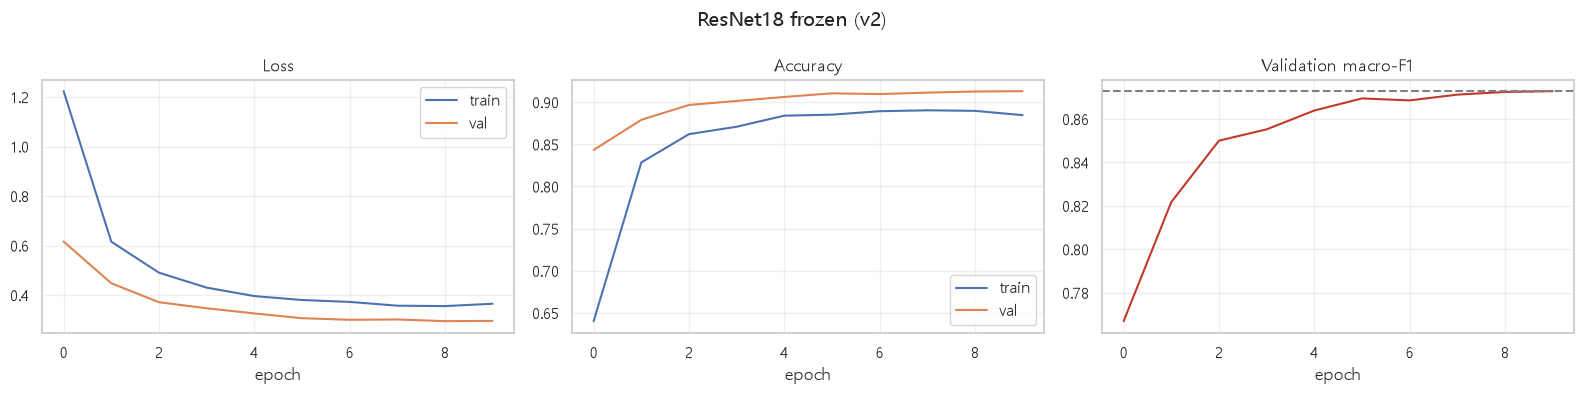

In [ ]:
results = {}

model_frozen = TransferModel(freeze=True)
hist_frozen = train_model(model_frozen, train_loader, val_loader,
                          epochs=EPOCHS_FROZEN, lr=LR_FROZEN,
                          ckpt_path=f"outputs/garbage/models/transfer_{SPLIT_TAG}_frozen.pt",
                          label="frozen")
results["frozen"] = hist_frozen
plot_history(hist_frozen, f"ResNet18 frozen ({SPLIT_TAG})")

## 5. 실험 2 — finetune (전체 미세조정)

동결을 풀고 backbone까지 학습한다. `pro1`에서 `freeze=True`만 써본 것을 한 걸음 더 나간 조건이다.

**학습률을 층마다 다르게 준다.** backbone은 이미 잘 학습된 상태라 크게 흔들면 오히려 망가진다.
head는 무작위 초기화 상태라 빠르게 배워야 한다. 그래서 backbone에 `lr / 10`, head에 `lr`을 준다.

**전체 학습률 자체도 낮춘다.** `frozen`은 5e-4였지만 여기서는 1e-4다. 사전학습 특징을
보존하면서 조금씩 우리 데이터에 맞추는 게 목적이기 때문이다.

파라미터 그룹별 학습률
  group 0: lr 1.0e-05 | 11,176,512 params
  group 1: lr 1.0e-04 | 6,156 params
[finetune]  1/15 loss 1.3406 val_loss 0.6994 val_acc 0.8257 val_f1 0.7369 lr 1.0e-04 (541s) 저장
[finetune]  2/15 loss 0.5469 val_loss 0.3792 val_acc 0.8937 val_f1 0.8420 lr 9.9e-05 (542s) 저장
[finetune]  3/15 loss 0.3600 val_loss 0.2735 val_acc 0.9234 val_f1 0.8868 lr 9.6e-05 (541s) 저장
[finetune]  4/15 loss 0.2780 val_loss 0.2349 val_acc 0.9320 val_f1 0.8992 lr 9.0e-05 (543s) 저장
[finetune]  5/15 loss 0.2232 val_loss 0.2067 val_acc 0.9406 val_f1 0.9116 lr 8.3e-05 (542s) 저장
[finetune]  6/15 loss 0.1924 val_loss 0.1923 val_acc 0.9445 val_f1 0.9178 lr 7.5e-05 (543s) 저장
[finetune]  7/15 loss 0.1677 val_loss 0.1777 val_acc 0.9488 val_f1 0.9244 lr 6.5e-05 (543s) 저장
[finetune]  8/15 loss 0.1551 val_loss 0.1706 val_acc 0.9505 val_f1 0.9277 lr 5.5e-05 (543s) 저장
[finetune]  9/15 loss 0.1372 val_loss 0.1629 val_acc 0.9505 val_f1 0.9274 lr 4.5e-05 (542s) 
[finetune] 10/15 loss 0.1313 val_loss 0.1557 val_acc 0.

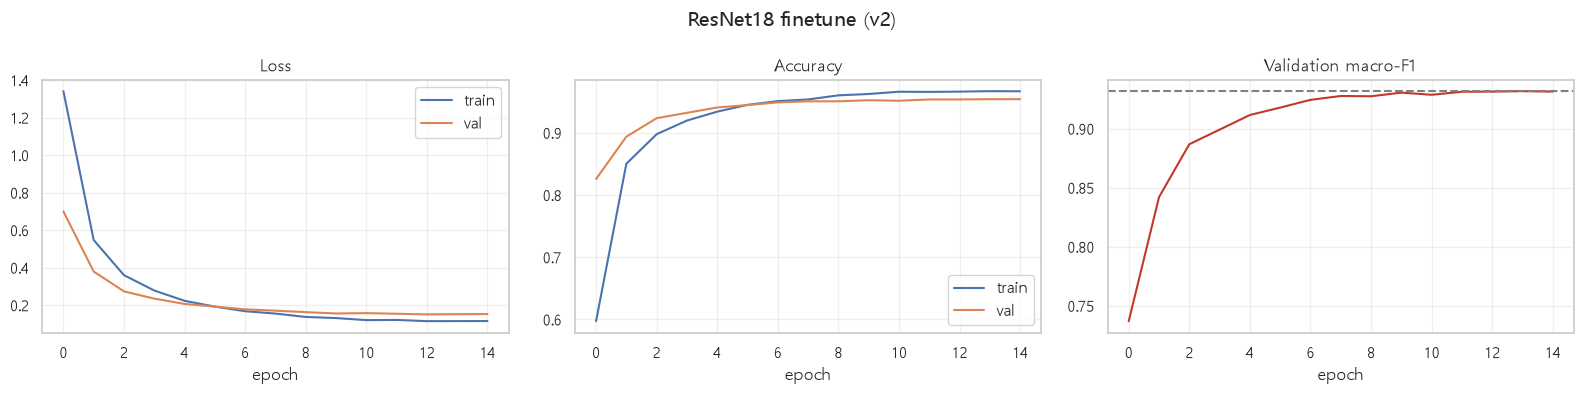

In [8]:
model_ft = TransferModel(freeze=False).to(device)

optimizer_ft = torch.optim.Adam([
    {"params": model_ft.backbone.parameters(), "lr": LR_FINETUNE * 0.1},
    {"params": model_ft.head.parameters(),     "lr": LR_FINETUNE},
])

print("파라미터 그룹별 학습률")
for i, g in enumerate(optimizer_ft.param_groups):
    print(f"  group {i}: lr {g['lr']:.1e} | {sum(p.numel() for p in g['params']):,} params")

hist_ft = train_model(model_ft, train_loader, val_loader,
                      epochs=EPOCHS_FINETUNE, lr=LR_FINETUNE,
                      optimizer=optimizer_ft,
                      ckpt_path=f"outputs/garbage/models/transfer_{SPLIT_TAG}_finetune.pt",
                      label="finetune")
results["finetune"] = hist_ft
plot_history(hist_ft, f"ResNet18 finetune ({SPLIT_TAG})")

## 6. 비교

`04`의 베이스라인 결과와 함께 본다. **여기서도 test는 쓰지 않는다.** 최종 모델 선정은
val macro-F1으로만 하고, test는 `06`에서 선정된 모델 하나에만 한 번 적용한다.

In [9]:
rows = []
for name, h in results.items():
    rows.append({"split": SPLIT_TAG,
                 "model": "ResNet18",
                 "exp": name,
                 "best_epoch": h["best_epoch"],
                 "val_macro_f1": round(h["best_macro_f1"], 4),
                 "val_accuracy": round(h["val_accuracy"][h["best_epoch"] - 1], 4),
                 "val_loss": round(h["val_loss"][h["best_epoch"] - 1], 4),
                 "epochs_run": len(h["loss"])})

exp_df = pd.DataFrame(rows)

exp_path = OUT / "metrics" / "experiments.csv"
if exp_path.exists():
    prev = pd.read_csv(exp_path)
    prev = prev[~((prev["split"] == SPLIT_TAG) & (prev["model"] == "ResNet18"))]
    exp_all = pd.concat([prev, exp_df], ignore_index=True)
else:
    exp_all = exp_df

exp_all.to_csv(exp_path, index=False, encoding="utf-8")

view = exp_all[exp_all["split"] == SPLIT_TAG].sort_values("val_macro_f1", ascending=False)
print(f"=== split {SPLIT_TAG} 전체 실험 ===")
print(view.to_string(index=False))

best_row = view.iloc[0]
print(f"\n최고: {best_row['model']} / {best_row['exp']} "
      f"(val macro-F1 {best_row['val_macro_f1']:.4f})")

=== split v2 전체 실험 ===
split      model      exp  best_epoch  val_macro_f1  val_accuracy  val_loss  epochs_run
   v2   ResNet18 finetune          14        0.9318        0.9539    0.1520          15
   v2   ResNet18   frozen          10        0.8728        0.9130    0.2955          10
   v2 GarbageCNN    plain          14        0.7013        0.7520    0.7397          15
   v2 GarbageCNN  sampler          13        0.6811        0.7051    0.8888          15
   v2 GarbageCNN weighted          15        0.6756        0.7064    0.9085          15

최고: ResNet18 / finetune (val macro-F1 0.9318)


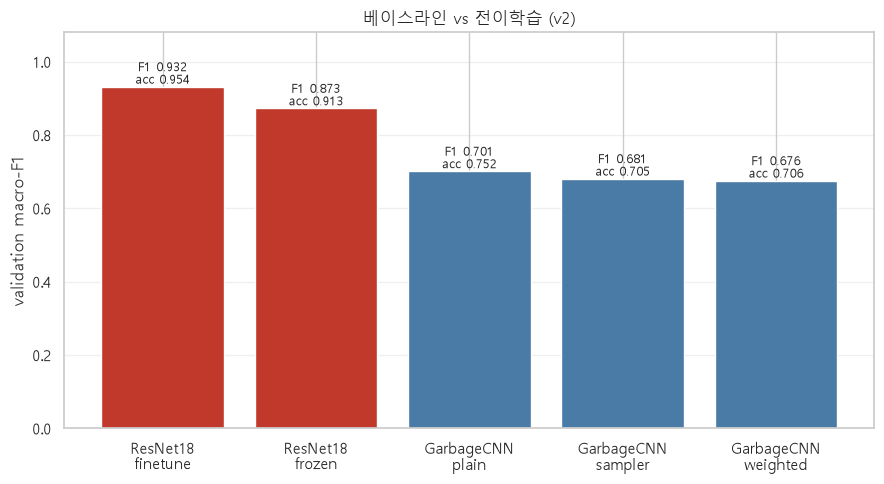

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{r['model']}\n{r['exp']}" for _, r in view.iterrows()]
colors = ["#c0392b" if r["model"] == "ResNet18" else "#4a7ba7"
          for _, r in view.iterrows()]

bars = ax.bar(labels, view["val_macro_f1"], color=colors)
for b, v, a in zip(bars, view["val_macro_f1"], view["val_accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008,
            f"F1 {v:.3f}\nacc {a:.3f}", ha="center", fontsize=9)

ax.set_ylabel("validation macro-F1")
ax.set_ylim(0, 1.08)
ax.set_title(f"베이스라인 vs 전이학습 ({SPLIT_TAG})")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT / "figures" / f"10_transfer_compare_{SPLIT_TAG}.png", dpi=150)
plt.show()

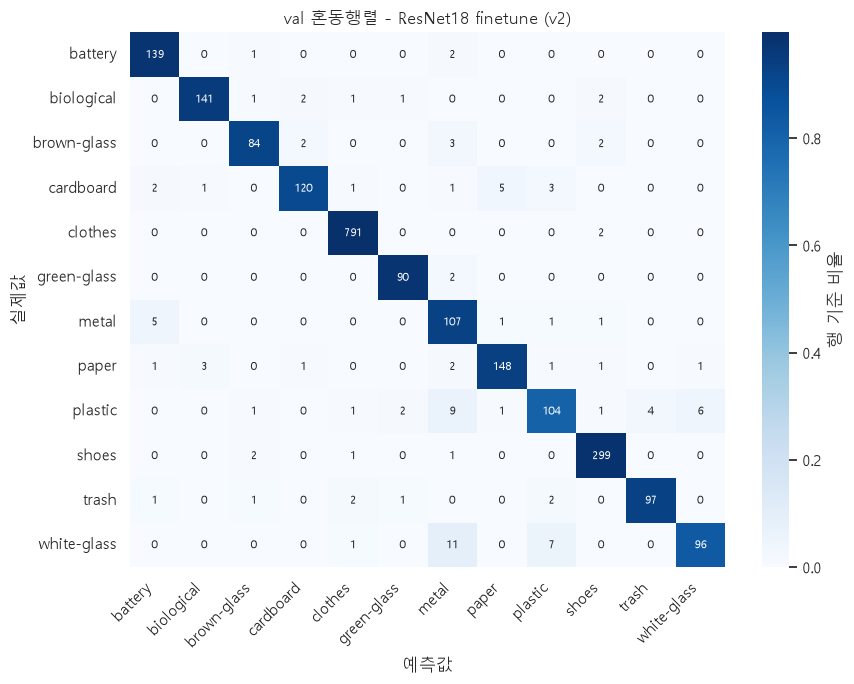

              precision    recall  f1-score   support

     battery     0.9392    0.9789    0.9586       142
  biological     0.9724    0.9527    0.9625       148
 brown-glass     0.9333    0.9231    0.9282        91
   cardboard     0.9600    0.9023    0.9302       133
     clothes     0.9912    0.9975    0.9943       793
 green-glass     0.9574    0.9783    0.9677        92
       metal     0.7754    0.9304    0.8458       115
       paper     0.9548    0.9367    0.9457       158
     plastic     0.8814    0.8062    0.8421       129
       shoes     0.9708    0.9868    0.9787       303
       trash     0.9604    0.9327    0.9463       104
 white-glass     0.9320    0.8348    0.8807       115

    accuracy                         0.9539      2323
   macro avg     0.9357    0.9300    0.9318      2323
weighted avg     0.9552    0.9539    0.9539      2323

accuracy 0.9539 | macro-F1 0.9318 | AUC 0.9982

주요 오분류 (실제 -> 예측)
  white-glass    -> metal          11건
  plastic        -> metal   

In [11]:
# 최고 모델의 val 혼동행렬
best_exp = best_row["exp"]
best_model = TransferModel(freeze=(best_exp == "frozen")).to(device)
best_model.load_state_dict(
    torch.load(f"outputs/garbage/models/transfer_{SPLIT_TAG}_{best_exp}.pt",
               map_location=device))

mv = evaluate(best_model, val_loader, nn.CrossEntropyLoss())
plot_confusion(mv, f"val 혼동행렬 - ResNet18 {best_exp} ({SPLIT_TAG})",
               save=OUT / "figures" / f"11_transfer_cm_{SPLIT_TAG}.png")

print(classification_report(mv["trues"], mv["preds"],
                            target_names=classes, digits=4, zero_division=0))
print(f"accuracy {mv['accuracy']:.4f} | macro-F1 {mv['macro_f1']:.4f} | AUC {mv['auc']:.4f}")

# 남은 오분류가 어디에 몰려 있는지
cm = confusion_matrix(mv["trues"], mv["preds"])
np.fill_diagonal(cm, 0)
pairs = [(classes[i], classes[j], int(cm[i, j]))
         for i in range(N_CLASSES) for j in range(N_CLASSES) if cm[i, j] > 0]
pairs.sort(key=lambda t: -t[2])
print("\n주요 오분류 (실제 -> 예측)")
for a, b, n in pairs[:10]:
    print(f"  {a:14s} -> {b:14s} {n}건")

## 정리

| 항목 | 내용 |
|---|---|
| backbone | ResNet18 (ImageNet 사전학습) |
| 입력 | 224px, ImageNet 정규화 |
| `frozen` | head만 학습, BN 통계까지 고정 |
| `finetune` | 전체 학습, backbone `lr/10` |
| 선정 지표 | val macro-F1 |

**강의 범위와의 관계.** 강의 `4_2_ResNet`, `4_3_EfficientNet`은 `include_top=True`로 사전학습
모델을 그대로 불러 추론만 했다. `pro1`(헬멧)에서 마지막 층을 교체해 재학습하는 데까지 나아갔고,
이 노트북은 거기서 **동결을 푸는 조건까지** 추가로 비교했다. 단계적으로 확장한 것이지
갑자기 다른 기법을 가져온 것이 아니다.

**두 번 돌릴 것.** `SPLIT_TAG`를 `"v2"`와 `"v1"`으로 각각 실행한다. `04`와 같은 값을 써야
`06`의 비교가 성립한다.

**다음 단계**: 지금까지 선정된 최고 모델을 test에 딱 한 번 적용한다.

→ `06_Eval.ipynb`